In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import sobel

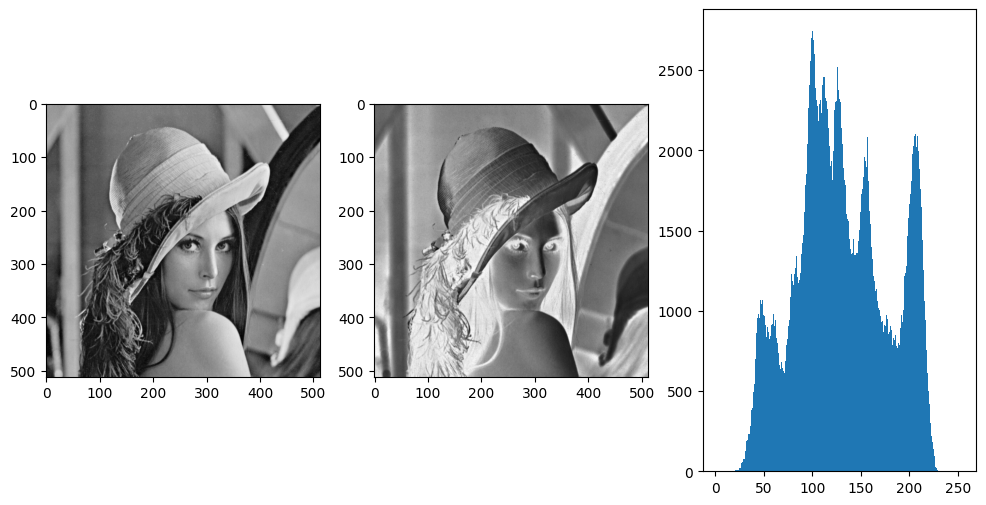

In [32]:
lena = Image.open('lena.bmp')
lena = np.array(lena.convert("L"))
#对图像求反
un_lena = 255 - lena

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.imshow(lena,cmap='gray')

plt.subplot(1,3,2)
plt.imshow(un_lena,cmap='gray')

plt.subplot(1,3,3)
plt.hist(un_lena.ravel(),256,[0,256])

plt.show()

In [39]:
from PIL import Image
import numpy as np
from scipy.ndimage import sobel

# 加载灰度图片
img_array = lena

# 计算梯度
grad_x = sobel(img_array, axis=0, mode='constant')
grad_y = sobel(img_array, axis=1, mode='constant')
grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)

# 阈值选择（这里需要根据散射图和实验结果来确定）
gray_threshold = 128  # 灰度阈值
grad_threshold = 50  # 梯度阈值

# 应用阈值进行分割
segmented_img = ((img_array > gray_threshold) & (grad_magnitude > grad_threshold)).astype(np.uint8) * 255

# 将分割结果转换为图像
segmented_img = Image.fromarray(segmented_img)
segmented_img.show()

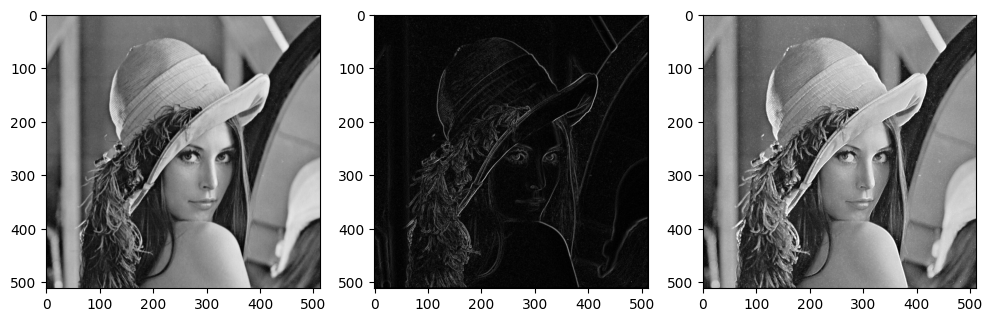